In [51]:
import pandas as pd

personality_data = pd.read_csv("data/Lab 3 - Personality Profile Type.csv")
personality_data.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [52]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [53]:
personality_data["type"].value_counts()

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64

In [54]:
personality_data["type"].nunique()

16

In [55]:
personality_data.shape

(8675, 2)

In [56]:
import random
random_indicies = random.sample(range(len(personality_data)), 10)
for i in random_indicies:
    print(f"index: {i}\nType: {personality_data['type'][i]}\nPosts: {personality_data['posts'][i]}\n\n")

index: 266
Type: ISTJ
Posts: 'ISTJ in university here, currently employed as an assistant librarian. In the past I've been a babysitter, clarinet tutor, shelver, and shop assistant.   If it pays the bills it pays the bills. I'd...|||What do you see? A slightly pudgy and highly nerdy redhead who 90% of the time has a deadpan expression.   Would you want to be friends with this person (aka yourself)? Possibly.    What role...|||Type 1 Gryffindor here.  I honestly expected to be placed in Hufflepuff or possibly Ravenclaw, but the Pottermore sorting hat has spoken. And even though I don't behave like a stereotypical...|||Quite frankly, I prefer being given money. That way I can spend it on something I actually need. I'm quite awkward with the whole receiving-presents thing in general though >.<|||Ah, let me see. Things that bug me about myself include:  1. Always needing to have the last word in. This is especially bad since I live in a family where everyone else needs to have the last wor

In [57]:
personality_data.duplicated().sum()

np.int64(0)

In [58]:
personality_data.isnull().sum()

type     0
posts    0
dtype: int64

In [59]:
personality_data["type"].value_counts(normalize=True)*100

type
INFP    21.118156
INFJ    16.945245
INTP    15.031700
INTJ    12.576369
ENTP     7.896254
ENFP     7.780980
ISTP     3.884726
ISFP     3.123919
ENTJ     2.662824
ISTJ     2.363112
ENFJ     2.190202
ISFJ     1.913545
ESTP     1.025937
ESFP     0.553314
ESFJ     0.484150
ESTJ     0.449568
Name: proportion, dtype: float64

In [60]:
classes_to_upsample = ["ENTJ", "ISTJ",
					    "ENFJ", "ISFJ", "ESTP", "ESFP", "ESFJ", "ESTJ"]
mask = personality_data["type"].isin(classes_to_upsample)
data_to_explode = personality_data[mask].copy()
data_to_explode["posts"] = data_to_explode["posts"].apply(lambda x: str(x).split("|||"))
exploded_subset = data_to_explode.explode("posts")
data_to_keep = personality_data[~mask].copy()
data_to_keep["posts"] = data_to_keep["posts"].apply(lambda x: str(x).replace("|||", " "))
exploded_data = pd.concat([data_to_keep, exploded_subset], ignore_index=True)
exploded_data = exploded_data.sample(frac=1, random_state=42).reset_index(drop=True)
exploded_data.head()

,type,posts
0,ISTJ,HA! :laughing: Liking people has nothing to d...
1,ESFJ,The slightest noise (other than breathing) and...
2,ENFJ,http://buttersafe.com/comics/2013-02-14-Fallin...
3,INFP,'Go to a career counselor. I'm doing this and ...
4,ENFJ,"Honestly, I'm not sure if there's any one part..."


In [61]:
exploded_data.shape

(56751, 2)

In [62]:
exploded_data["type"].value_counts(normalize=True)*100

type
ENTJ    19.863967
ISTJ    17.467534
ENFJ    16.366231
ISFJ    14.309880
ESTP     7.642156
ESFP     3.903015
ESFJ     3.555884
ESTJ     3.384962
INFP     3.228137
INFJ     2.590263
INTP     2.297757
INTJ     1.922433
ENTP     1.207027
ENFP     1.189406
ISTP     0.593822
ISFP     0.477525
Name: proportion, dtype: float64

In [63]:
exploded_data["type"].value_counts()

type
ENTJ    11273
ISTJ     9913
ENFJ     9288
ISFJ     8121
ESTP     4337
ESFP     2215
ESFJ     2018
ESTJ     1921
INFP     1832
INFJ     1470
INTP     1304
INTJ     1091
ENTP      685
ENFP      675
ISTP      337
ISFP      271
Name: count, dtype: int64

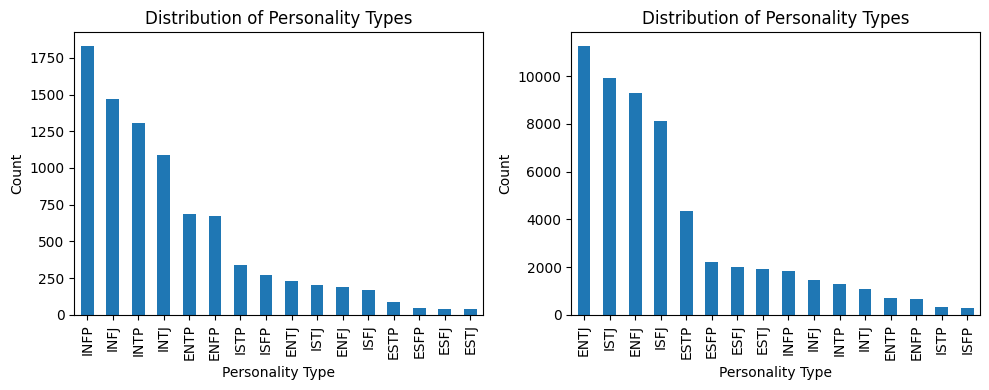

In [64]:
import matplotlib.pyplot as plt

figsize, axis = plt.subplots(1, 2 ,figsize=(10, 4))
personality_data["type"].value_counts().plot(kind="bar", ax=axis[0], title="Original Data")
axis[0].set_xlabel("Personality Type")
axis[0].set_ylabel("Count")
axis[0].set_title("Distribution of Personality Types")

exploded_data["type"].value_counts().plot(kind="bar", ax=axis[1], title="Upsampled Data")
axis[1].set_xlabel("Personality Type")
axis[1].set_ylabel("Count")
axis[1].set_title("Distribution of Personality Types")
plt.tight_layout()
plt.show()

In [65]:
empty_rows = exploded_data[exploded_data["posts"].str.strip() == ""]
print(f"Number of empty rows: {len(empty_rows)}")

Number of empty rows: 108


In [66]:
exploded_data_cleaned = exploded_data[exploded_data["posts"].str.strip() != ""]
print(f"Rows before cleaning: {len(exploded_data)}")
print(f"Rows after cleaning: {len(exploded_data_cleaned)}")

Rows before cleaning: 56751
Rows after cleaning: 56643


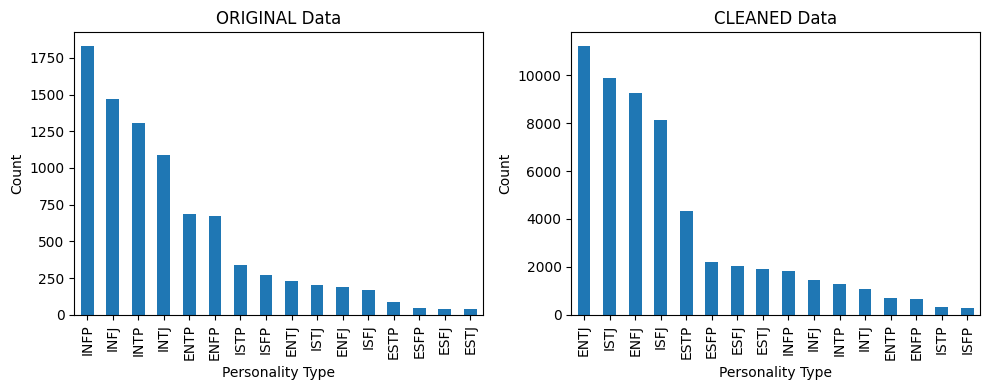

In [67]:
import matplotlib.pyplot as plt

figsize, axis = plt.subplots(1, 2 ,figsize=(10, 4))
personality_data["type"].value_counts().plot(kind="bar", ax=axis[0])
axis[0].set_xlabel("Personality Type")
axis[0].set_ylabel("Count")
axis[0].set_title("ORIGINAL Data")

exploded_data_cleaned["type"].value_counts().plot(kind="bar", ax=axis[1])
axis[1].set_xlabel("Personality Type")
axis[1].set_ylabel("Count")
axis[1].set_title("CLEANED Data")
plt.tight_layout()
plt.show()

In [68]:
from sklearn.base import BaseEstimator, TransformerMixin
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
import contractions
from nltk.tokenize import word_tokenize

class Clean_Text(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.lemmetizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words("english"))
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X: pd.Series):
        X =  X.copy()
        X_transformed = X.apply(self.Cleaner)
        return X_transformed
    
    def Cleaner(self, text):
        text = re.sub(r'http[s]?://\S+', '', str(text)).lower()
        text = contractions.fix(text)
        text = re.sub(r'[^a-z\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = word_tokenize(text)
        tokens = [self.lemmetizer.lemmatize(word) for word in tokens if word not in self.stop_words]
        return ' '.join(tokens)
        

In [69]:
from sklearn.pipeline import Pipeline
test_pipeline = Pipeline([
    ("clean_text", Clean_Text())
])
cleaned_post_test = test_pipeline.fit_transform(exploded_data_cleaned["posts"])
cleaned_post_test.shape

(56643,)

In [70]:
cleaned_post_test.head()

0    ha laughing liking people nothing help less ab...
1    slightest noise breathing sleep fan radio defi...
2                                                     
3    go career counselor much easier change young c...
4    honestly sure one particular thing make j laug...
Name: posts, dtype: object

In [71]:
empty_data = cleaned_post_test[cleaned_post_test.str.strip() == ""]
empty_data.shape

(1351,)

In [72]:
empty_data

2         
77        
95        
96        
134       
        ..
56650     
56652     
56686     
56694     
56713     
Name: posts, Length: 1351, dtype: object

In [73]:
exploded_data["Cleaned_Posts"] = cleaned_post_test
exploded_data.head()

,type,posts,Cleaned_Posts
0,ISTJ,HA! :laughing: Liking people has nothing to d...,ha laughing liking people nothing help less ab...
1,ESFJ,The slightest noise (other than breathing) and...,slightest noise breathing sleep fan radio defi...
2,ENFJ,http://buttersafe.com/comics/2013-02-14-Fallin...,
3,INFP,'Go to a career counselor. I'm doing this and ...,go career counselor much easier change young c...
4,ENFJ,"Honestly, I'm not sure if there's any one part...",honestly sure one particular thing make j laug...


In [74]:
final_cleaned_data = exploded_data[exploded_data["Cleaned_Posts"].str.strip() != ""].reset_index(drop=True)
final_cleaned_data.head()

,type,posts,Cleaned_Posts
0,ISTJ,HA! :laughing: Liking people has nothing to d...,ha laughing liking people nothing help less ab...
1,ESFJ,The slightest noise (other than breathing) and...,slightest noise breathing sleep fan radio defi...
2,INFP,'Go to a career counselor. I'm doing this and ...,go career counselor much easier change young c...
3,ENFJ,"Honestly, I'm not sure if there's any one part...",honestly sure one particular thing make j laug...
4,ENFJ,^^; dont do things that can damage your health...,thing damage health shocked silly


In [75]:
final_cleaned_data.isnull().sum()

type               0
posts              0
Cleaned_Posts    108
dtype: int64

In [76]:
final_cleaned_data.dropna(inplace=True)
final_cleaned_data.isnull().sum()

type             0
posts            0
Cleaned_Posts    0
dtype: int64

In [77]:
print(f"shape: {final_cleaned_data.shape}")
print(final_cleaned_data["type"].value_counts())

shape: (55292, 3)
type
ENTJ    10952
ISTJ     9576
ENFJ     9084
ISFJ     7825
ESTP     4199
ESFP     2136
ESFJ     1989
ESTJ     1867
INFP     1831
INFJ     1470
INTP     1304
INTJ     1091
ENTP      685
ENFP      675
ISTP      337
ISFP      271
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(final_cleaned_data["Cleaned_Posts"], final_cleaned_data["type"], test_size=0.2, random_state=42,
                                                    stratify=final_cleaned_data["type"], shuffle=True)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42,
                                                      stratify=y_train, shuffle=True)
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_valid.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 35386 samples
Validation: 8847 samples
Test: 11059 samples


In [95]:
import torch.nn as nn

class GRU_Model(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.RLU = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        embedd = self.embedding(x)
        gru_output, hidden = self.gru(embedd)
        output = self.RLU(gru_output[:, -1, :])
        output = self.dropout(output)
        output = self.fc(output)
        return output

In [80]:
from collections import Counter

all_text = " ".join(final_cleaned_data["Cleaned_Posts"])
word_counts = Counter(all_text.split())
frequent_words = [word for word, count in word_counts.items() if count >= 3]
print(f"Number of unique words: {len(word_counts)}")
print(f"Unique words after filtering: {len(frequent_words)}")

Number of unique words: 88766
Unique words after filtering: 35123


In [81]:
vocab = ["<PAD>", "<UNK>"] + frequent_words
vocab_size = len(vocab)
w2i = {word: idx for idx, word in enumerate(vocab)}
i2w = {idx: word for idx, word in enumerate(vocab)}
print(f"index for pad is:{w2i['<PAD>']}\nindex for unk is:{w2i['<UNK>']}")
print(f"index of 100 its word is:{i2w[100]}")

index for pad is:0
index for unk is:1
index of 100 its word is:setting


In [82]:
import torch
from sklearn.base import BaseEstimator, TransformerMixin
class TextToVector(BaseEstimator, TransformerMixin):
    def __init__(self, w2i, max_len):
        self.w2i = w2i
        self.max_len = max_len
    
    def fit(self, X, y=None):
        return self
    
    def encode_pad_seq(self, seq):
        encoded = [self.w2i.get(word, self.w2i["<UNK>"]) for word in str(seq).split()]
        
        if len(encoded) > self.max_len:
            return encoded[:self.max_len]
         
        elif len(encoded) < self.max_len:
            return encoded + [self.w2i["<PAD>"]] * (self.max_len - len(encoded))
        else:
            return encoded
    
    def transform(self, X):
        encoded = X.apply(self.encode_pad_seq)
        encoded_list = encoded.tolist()
        return torch.tensor(encoded_list, dtype=torch.long)

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [84]:
final_pipeline = Pipeline([
    ("cleaner", Clean_Text()),
    ("vectorizer", TextToVector(w2i, max_len=100))
])
final_pipeline.fit(X_train)
X_train_vectorized = final_pipeline.transform(X_train)
X_train_vectorized.shape

d:\anaconda\envs\iti-nlp\lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


torch.Size([35386, 100])

In [85]:
X_valid_vectorized = final_pipeline.transform(X_valid)
X_valid_vectorized.shape

torch.Size([8847, 100])

In [86]:
X_test_vectorized = final_pipeline.transform(X_test)
X_test_vectorized.shape

torch.Size([11059, 100])

In [87]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
y_test_encoded = label_encoder.transform(y_test)
print(f"Encoded labels: {label_encoder.classes_}")
print(f"length is: {len(label_encoder.classes_)}")

Encoded labels: ['ENFJ' 'ENFP' 'ENTJ' 'ENTP' 'ESFJ' 'ESFP' 'ESTJ' 'ESTP' 'INFJ' 'INFP'
 'INTJ' 'INTP' 'ISFJ' 'ISFP' 'ISTJ' 'ISTP']
length is: 16


In [88]:
y_train_encoded = torch.tensor(y_train_encoded, dtype=torch.long)
y_valid_encoded = torch.tensor(y_valid_encoded, dtype=torch.long)
y_test_encoded = torch.tensor(y_test_encoded, dtype=torch.long)

In [89]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_vectorized, y_train_encoded)
valid_dataset = TensorDataset(X_valid_vectorized, y_valid_encoded)
test_dataset = TensorDataset(X_test_vectorized, y_test_encoded)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [90]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [96]:
from sklearn.metrics import classification_report
criterion = nn.CrossEntropyLoss()
model = GRU_Model(vocab_size=vocab_size, emb_dim=100, hidden_dim=128, num_classes=len(label_encoder.classes_))
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.to(device)
patience = 20
best_val_loss = float('inf')
epoch_no_improve = 0
number_epochs = 200
train_losses = []
valid_losses = []
for i in range(number_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in valid_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    avg_valid_loss = val_loss / len(valid_loader)
    valid_losses.append(avg_valid_loss)
    print(f"Epoch {i+1}, Loss: {avg_loss:.4f}, Val Loss: {avg_valid_loss:.4f}")
    
    if avg_valid_loss < best_val_loss:
        best_val_loss = avg_valid_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {i+1}. Stopping training.")
            break

Epoch 1, Loss: 1.9608, Val Loss: 1.9027
Epoch 2, Loss: 1.9044, Val Loss: 1.8936
Epoch 3, Loss: 1.8890, Val Loss: 1.8875
Epoch 4, Loss: 1.8566, Val Loss: 1.8597
Epoch 5, Loss: 1.8006, Val Loss: 1.8550
Epoch 6, Loss: 1.7363, Val Loss: 1.8558
Validation loss did not improve. Patience: 1/20
Epoch 7, Loss: 1.6672, Val Loss: 1.8748
Validation loss did not improve. Patience: 2/20
Epoch 8, Loss: 1.5935, Val Loss: 1.9118
Validation loss did not improve. Patience: 3/20
Epoch 9, Loss: 1.5217, Val Loss: 1.9519
Validation loss did not improve. Patience: 4/20
Epoch 10, Loss: 1.4492, Val Loss: 2.0241
Validation loss did not improve. Patience: 5/20
Epoch 11, Loss: 1.3748, Val Loss: 2.0799
Validation loss did not improve. Patience: 6/20
Epoch 12, Loss: 1.3054, Val Loss: 2.1746
Validation loss did not improve. Patience: 7/20
Epoch 13, Loss: 1.2413, Val Loss: 2.2307
Validation loss did not improve. Patience: 8/20
Epoch 14, Loss: 1.1735, Val Loss: 2.3492
Validation loss did not improve. Patience: 9/20
Epo

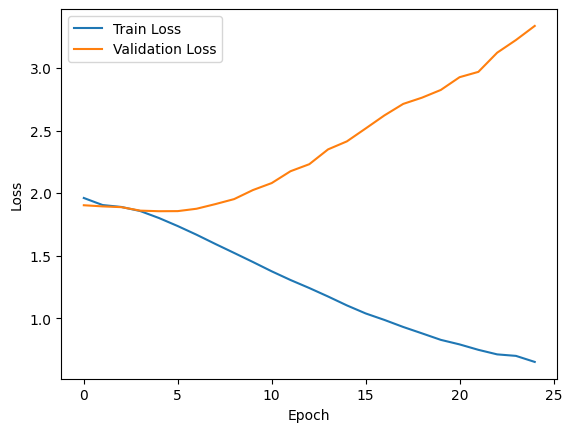

In [97]:
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [98]:
f1_score = classification_report(y_valid_encoded.cpu(), model(X_valid_vectorized.to(device)).argmax(dim=1).cpu(), target_names=label_encoder.classes_)
print(f1_score)

              precision    recall  f1-score   support

        ENFJ       0.30      0.27      0.28      1453
        ENFP       0.32      0.30      0.31       108
        ENTJ       0.33      0.31      0.32      1752
        ENTP       0.18      0.17      0.18       110
        ESFJ       0.09      0.06      0.07       318
        ESFP       0.10      0.02      0.03       342
        ESTJ       0.18      0.04      0.07       299
        ESTP       0.17      0.16      0.16       672
        INFJ       0.42      0.39      0.40       235
        INFP       0.40      0.41      0.41       293
        INTJ       0.32      0.32      0.32       175
        INTP       0.36      0.46      0.40       209
        ISFJ       0.26      0.32      0.29      1252
        ISFP       0.04      0.02      0.03        43
        ISTJ       0.27      0.38      0.32      1532
        ISTP       0.09      0.06      0.07        54

    accuracy                           0.28      8847
   macro avg       0.24   

In [99]:
f1_score_testdata = classification_report(y_test_encoded.cpu(), model(X_test_vectorized.to(device)).argmax(dim=1).cpu(), target_names=label_encoder.classes_)
print(f1_score_testdata)

              precision    recall  f1-score   support

        ENFJ       0.33      0.28      0.30      1817
        ENFP       0.27      0.22      0.24       135
        ENTJ       0.33      0.32      0.32      2191
        ENTP       0.26      0.28      0.27       137
        ESFJ       0.12      0.08      0.10       398
        ESFP       0.04      0.01      0.02       427
        ESTJ       0.17      0.03      0.05       374
        ESTP       0.17      0.15      0.16       840
        INFJ       0.43      0.40      0.41       294
        INFP       0.42      0.43      0.42       366
        INTJ       0.31      0.31      0.31       218
        INTP       0.32      0.39      0.35       261
        ISFJ       0.27      0.34      0.30      1565
        ISFP       0.09      0.06      0.07        54
        ISTJ       0.26      0.36      0.30      1915
        ISTP       0.13      0.09      0.11        67

    accuracy                           0.28     11059
   macro avg       0.24   